In [2]:
import pandas as pd
from gensim.models import KeyedVectors

train_data = pd.read_csv('train_data.csv')
test_data = pd.read_csv('test_data.csv')

In [45]:
# Path to your .vec files
model_path_en = 'wiki.en.small.vec'
model_path_ro = 'wiki.ro.small.vec'

model_en = KeyedVectors.load_word2vec_format(model_path_en, binary=False, limit=100000)
model_ro = KeyedVectors.load_word2vec_format(model_path_ro, binary=False, limit=100000)

In [28]:
train_data = train_data.dropna()
train_data.isna().sum()

english     0
romanian    0
dtype: int64

In [48]:
import re
import numpy as np
ex = train_data['english'][0].lower().split(' ')
def get_sentence_embedding(en_data, ro_data):
    en_embs, ro_embs = [], []
    for en_sentence, ro_sentence in zip(en_data, ro_data):

        tokens = re.findall(r"\b\w+\b", en_sentence.lower())
        en_sentence_emb = np.array([model_en[token] for token in tokens if token in model_en]).mean(axis=0)
        if len(en_sentence_emb.shape) != 1:
            continue

        tokens = re.findall(r"\b\w+\b", ro_sentence.lower())
        ro_sentence_emb = np.array([model_ro[token] for token in tokens if token in model_ro]).mean(axis=0)
        if len(ro_sentence_emb.shape) != 1:
            continue

        en_embs.append(en_sentence_emb)
        ro_embs.append(ro_sentence_emb)

    return np.array(en_embs), np.array(ro_embs)

en_embs, ro_embs = get_sentence_embedding(train_data['english'].tolist(), train_data['romanian'].tolist())
en_embs.shape, ro_embs.shape

C:\Users\raian\AppData\Local\Temp\ipykernel_27228\1462208844.py:14: RuntimeWarning: Mean of empty slice
  ro_sentence_emb = np.array([model_ro[token] for token in tokens if token in model_ro]).mean(axis=0)
c:\Users\raian\source\repos\AI\.env\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\raian\AppData\Local\Temp\ipykernel_27228\1462208844.py:9: RuntimeWarning: Mean of empty slice
  en_sentence_emb = np.array([model_en[token] for token in tokens if token in model_en]).mean(axis=0)


((15141, 300), (15141, 300))

<Axes: >

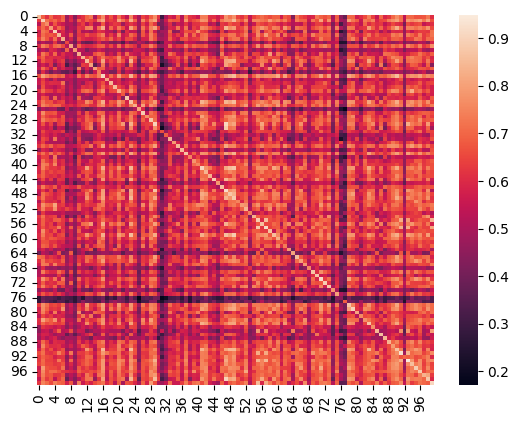

In [51]:
from scipy.linalg import orthogonal_procrustes
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

W, _ = orthogonal_procrustes(ro_embs, en_embs)

small_en_emb = en_embs[:100, :]
small_ro_emb = ro_embs[:100, :]
translated_emb = small_ro_emb @ W
sim_mat = cosine_similarity(small_en_emb, translated_emb)
sns.heatmap(sim_mat)

In [ ]:
def vec_text(text):
    return text

[('kings', 0.6761605143547058),
 ('queen', 0.6493092775344849),
 ('monarch', 0.6260097026824951),
 ('kingship', 0.5977715253829956),
 ('throne', 0.5953187346458435),
 ('reign', 0.569341242313385),
 ('reigned', 0.5637271404266357),
 ('prince', 0.544633686542511),
 ('kingdom', 0.5387711524963379),
 ('abdicated', 0.5370364785194397)]